In [2]:
import sys
sys.path.insert(0, '..')

from utils.models import CNNLSTM
from utils.preprocessing import FEATURES, normalize_label_name, preprocess_data
from utils.evaluation import (
    evaluate_model,
    load_and_evaluate_cnnlstm_model,
)
import torch
import torch.nn as nn
import joblib
import pandas as pd
import numpy as np

In [3]:
df_cicids2017 = preprocess_data("../data/CICIDS2017/wednesday_labeled.tsv")
df_ciciot2023 = preprocess_data("../data/CICIoT2023/ciciot2023_labeled_conn.tsv")

In [4]:
label_column = "label"

df_cicids2017 = df_cicids2017[df_cicids2017["label"].isin(["DOS_HTTP_FLOOD"] + ["BENIGN"])]
X_cicids = df_cicids2017.drop(columns=[label_column])
y_cicids = df_cicids2017[label_column]

X_ciciot = df_ciciot2023.drop(columns=[label_column])
y_ciciot = df_ciciot2023[label_column]

print("CICIDS test shape:", X_cicids.shape)
print("CICIoT test shape:", X_ciciot.shape)

CICIDS test shape: (481829, 7)
CICIoT test shape: (1850844, 7)


# Load Models

Evaluation for CICIoT2023-trained CNNLSTM tested on CICIDS2017:

=== CICIoT2023-trained CNNLSTM tested on CICIDS2017 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.6975    0.9546    0.8060    327060
DOS_HTTP_FLOOD     0.5656    0.1249    0.2047    154769

      accuracy                         0.6881    481829
     macro avg     0.6315    0.5398    0.5053    481829
  weighted avg     0.6551    0.6881    0.6129    481829


=== Per-Label Accuracy ===

BENIGN: 0.9546
DOS_HTTP_FLOOD: 0.1249


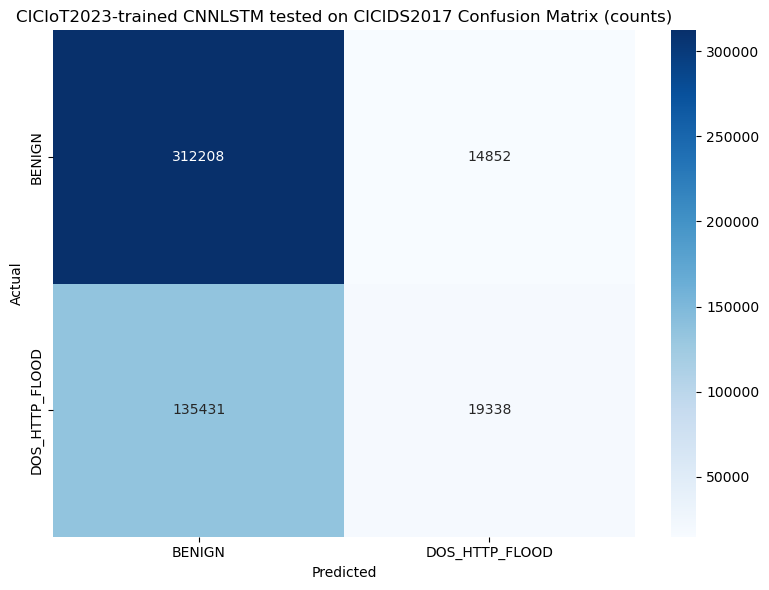

In [ ]:
load_and_evaluate_cnnlstm_model(
    joblib_path="models/cnnlstm_property_ciciot2023.joblib",
    X=X_cicids,
    y_true=y_cicids,
    model_name="CICIoT2023-trained CNNLSTM tested on CICIDS2017"
)

In [ ]:
load_and_evaluate_cnnlstm_model(
    joblib_path="models/cnnlstm_property_cicids2017.joblib",
    X=X_cicids,
    y_true=y_cicids,
    model_name="CICIoT2023-trained CNNLSTM tested on CICIDS2017"
)